<a href="https://colab.research.google.com/github/danielrosetti07/Trabalhos-Faculdade/blob/main/Top500_Filmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trabalho realizado por: Daniel Rosetti da Rocha Ribeiro e Douglas Rosetti da Rocha Ribeiro

#Análise Exploratória dos Top 500 filmes mais bem avaliados


O objetivo deste trabalho é realizar uma análise exploratória de dados utilizando uma base com os 500 filmes mais bem avaliados. A partir dos dados disponíveis, serão investigadas características como notas, gêneros, anos de lançamento, diretores e outros aspectos relevantes.

Por meio de perguntas, estatísticas e gráficos, busca-se identificar padrões e curiosidades presentes na base de dados, tornando mais fácil compreender quais características são comuns entre os filmes mais bem avaliados.

In [1]:
##Importação das bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import itertools

In [2]:
##Importação do dataset
df = pd.read_csv("/content/drive/MyDrive/Top 500 Movies Ranked by Combined Critics and Audience Scores.csv")

In [3]:
##Criação de uma cópia do dataset original
df_limpo = df.copy()

In [4]:
##Limpeza dos dados
df_limpo.drop(columns=['imdbID'], inplace=True)
df_limpo.drop(columns=['RT_URL'], inplace=True)
df_limpo.drop(columns=['Plot'], inplace=True)
df_limpo.drop(columns=['Language'], inplace=True)

In [5]:
df_limpo.columns

Index(['Rank', 'Title', 'Year', 'Genre', 'Director', 'Cast', 'Awards',
       'Production', 'Flickmetrix_Score', 'IMDb_10', 'IMDb_100', 'IMDb_Votes',
       'Metacritic', 'Critic_Rating_RT', 'Critic_Reviews', 'Audience_Rating',
       'Audience_Reviews', 'Letterboxd', 'Letterboxd_Votes', 'Google_Score',
       'Streaming_On', 'Custom_Score'],
      dtype='object')

In [6]:
##Informações base do dataset
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               449 non-null    int64  
 1   Title              449 non-null    object 
 2   Year               449 non-null    int64  
 3   Genre              449 non-null    object 
 4   Director           449 non-null    object 
 5   Cast               448 non-null    object 
 6   Awards             324 non-null    object 
 7   Production         329 non-null    object 
 8   Flickmetrix_Score  449 non-null    float64
 9   IMDb_10            449 non-null    float64
 10  IMDb_100           449 non-null    float64
 11  IMDb_Votes         449 non-null    int64  
 12  Metacritic         436 non-null    float64
 13  Critic_Rating_RT   449 non-null    float64
 14  Critic_Reviews     449 non-null    int64  
 15  Audience_Rating    401 non-null    float64
 16  Audience_Reviews   442 non

In [7]:
##Descrição simples do dataset
df.describe()

,Rank,Year,Flickmetrix_Score,IMDb_10,IMDb_100,IMDb_Votes,Metacritic,Critic_Rating_RT,Critic_Reviews,Audience_Rating,Audience_Reviews,Letterboxd,Letterboxd_Votes,Google_Score,Custom_Score
count,449.000000,449.000000,449.000000,449.000000,449.000000,4.490000e+02,436.000000,449.000000,449.000000,401.000000,4.420000e+02,449.000000,4.480000e+02,446.000000,449.000000
mean,225.000000,1994.151448,83.884187,7.969488,79.694878,4.315229e+05,86.754587,85.581292,122.926503,85.748130,8.115906e+05,82.151448,7.029797e+05,85.807175,84.229866
std,129.759393,25.683153,2.685102,0.359911,3.599106,4.723575e+05,6.924011,4.844751,67.931731,5.018357,3.179307e+06,3.954457,7.575711e+05,5.459435,2.798203
min,1.000000,1920.000000,80.000000,7.100000,71.000000,1.194000e+04,65.000000,72.000000,50.000000,57.000000,1.759300e+04,68.000000,3.153500e+04,46.000000,77.000000
25%,113.000000,1976.000000,82.000000,7.700000,77.000000,1.019410e+05,82.000000,82.000000,70.000000,83.000000,7.716325e+04,80.000000,1.430270e+05,83.000000,82.170000
50%,225.000000,2003.000000,83.000000,8.000000,80.000000,2.312560e+05,87.000000,85.000000,100.000000,87.000000,1.982740e+05,82.000000,3.962565e+05,86.000000,83.670000
75%,337.000000,2015.000000,85.000000,8.200000,82.000000,6.460640e+05,92.000000,89.000000,156.000000,89.000000,5.818142e+05,84.000000,1.002294e+06,90.000000,86.000000
max,449.000000,2025.000000,93.000000,9.200000,92.000000,2.666368e+06,100.000000,98.000000,342.000000,95.000000,2.454920e+07,92.000000,3.771374e+06,98.000000,93.830000


#Qual é os 10 diretores que mais aparece no top 500 e a média das notas?

In [8]:
director_imdb_scores = []
for index, row in df_limpo.iterrows():
  directors = [d.strip() for d in row['Director'].split(',')]
  for director in directors:
    director_imdb_scores.append({'Director': director, 'IMDb_10_Score': row['IMDb_10']})

director_scores_df = pd.DataFrame(director_imdb_scores)
director_summary = director_scores_df.groupby('Director').agg(
    movie_count=('IMDb_10_Score', 'count'),
    mean_imdb_score=('IMDb_10_Score', 'mean')
).sort_values(by='movie_count', ascending=False)
director_summary.head(10).round(2)

,movie_count,mean_imdb_score
Director,,
Steven Spielberg,8,8.24
Martin Scorsese,8,8.11
Hayao Miyazaki,7,8.00
Stanley Kubrick,7,8.27
Alfred Hitchcock,7,8.17
Quentin Tarantino,6,8.38
Wes Anderson,6,7.77
Christopher Nolan,5,8.40
Denis Villeneuve,5,8.08


A maioria dos diretores com múltiplos filmes no Top 500 demonstram uma notável consistência em suas avaliações, com médias de IMDb que variam, para os top 10 em quantidade, entre 7.77 (Wes Anderson) e 8.40 (Christopher Nolan). Isso sugere que esses diretores são consistentemente bem avaliados tanto pela crítica quanto pelo público, resultando em filmes de alta qualidade.

#Atores com mais participações em filmes bem avaliados

In [9]:
atores = df_limpo['Cast'].str.split(',').explode().str.strip()
atores_contador = atores.value_counts()
atores_contador.head(10)

,count
Cast,
Robert De Niro,10
Tom Hanks,7
Leonardo DiCaprio,7
Ralph Fiennes,6
Matt Damon,6
James Stewart,6
Harrison Ford,6
Ethan Hawke,5
Harvey Keitel,5


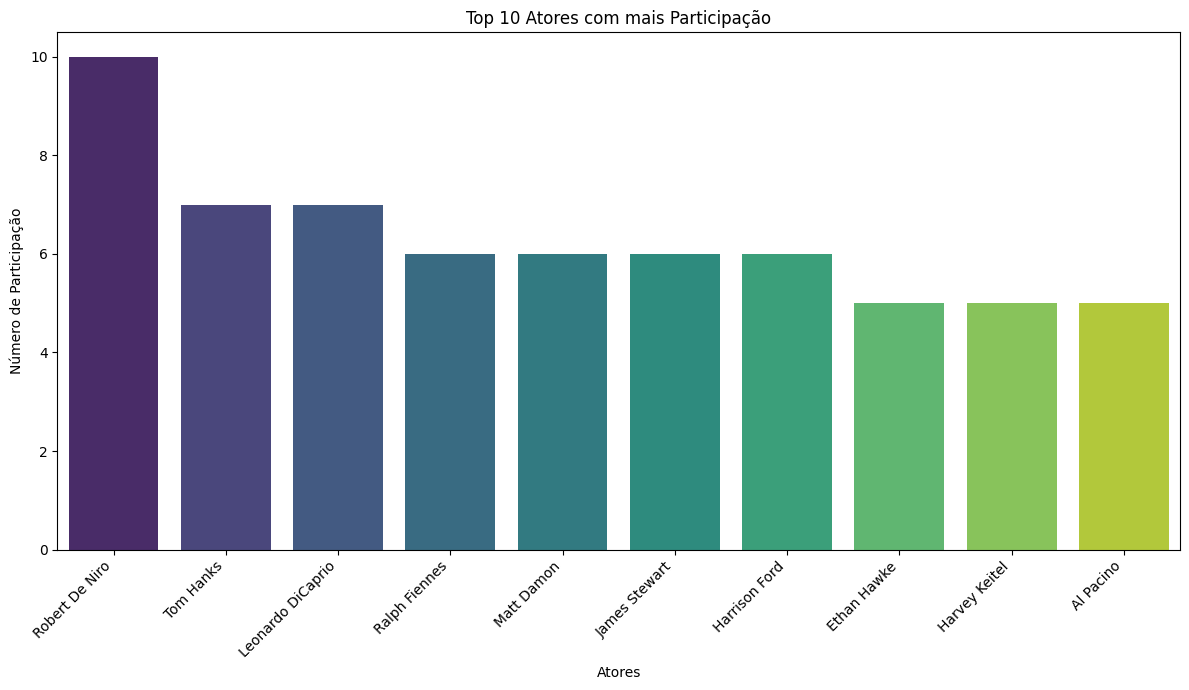

In [10]:
top_10_actors =  atores_contador.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_actors.index, y=top_10_actors.values, palette='viridis', hue=top_10_actors.index, legend=False)

plt.title('Top 10 Atores com mais Participação')
plt.xlabel('Atores')
plt.ylabel('Número de Participação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Os dados revelam que alguns atores têm uma presença marcante em filmes de alta classificação. Por exemplo, Robert De Niro lidera com 10 participações, seguido por Tom Hanks e Leonardo DiCaprio com 7 cada. Isso sugere que a presença desses atores pode ser um fator indicativo de filmes bem avaliados, potencialmente devido à sua capacidade de escolher bons projetos ou ao seu talento em atuação, que contribui para a qualidade geral da produção.

#Qual o gênero mais aclamados pelos críticos?

In [11]:
generos = df_limpo['Genre'].str.split(',').explode().str.strip()
generos_contador = generos.value_counts()
generos_contador.head(10)

,count
Genre,
Drama,297
Thriller,92
Comedy,88
Romance,76
Crime,68
Adventure,64
Action,52
Animation,51
Fantasy,47


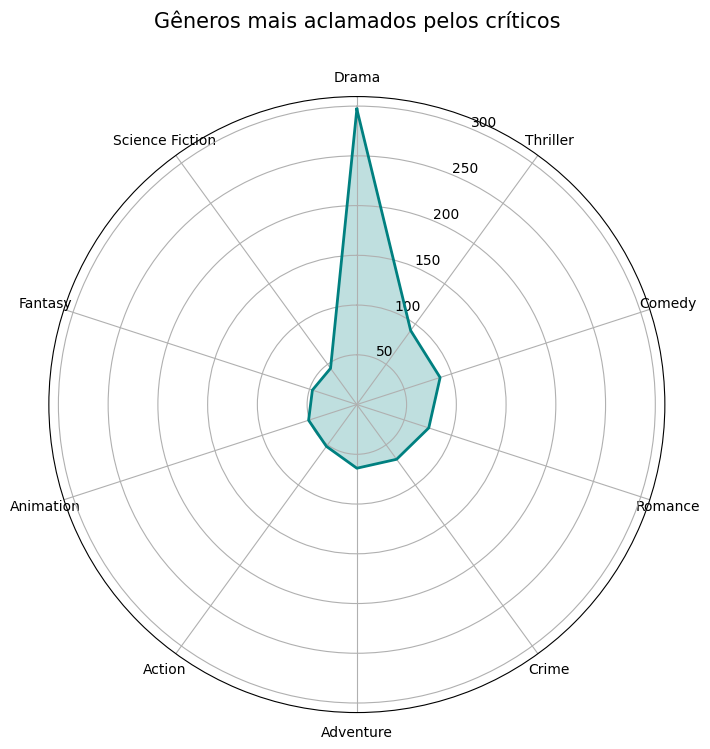

In [12]:
genre_counts = generos_contador.head(10)
labels = genre_counts.index.tolist()
values = genre_counts.values.tolist()

num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

values += values[:1]
angles += angles[:1]
labels += labels[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.fill(angles, values, color='teal', alpha=0.25)
ax.plot(angles, values, color='teal', linewidth=2)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels[:-1])

plt.title('Gêneros mais aclamados pelos críticos', size=15, y=1.1)
plt.show()

A análise dos gêneros revela que 'Drama' é o gênero dominante entre os 500 filmes mais bem avaliados, com 297 ocorrências. Gêneros como 'Suspense', 'Comédia' e 'Romance' também são bastante representados. Essa distribuição sugere que filmes com foco em narrativas dramáticas, complexidade emocional e desenvolvimento de personagens tendem a ser mais frequentemente aclamados pela crítica e pelo público, compondo a maior parte dos filmes de alta classificação neste dataset.

#Qual a nota média dos anos que mais aparece?

In [13]:
year_imdb_scores = df_limpo[['Year', 'IMDb_10']]
year_summary = year_imdb_scores.groupby('Year').agg(
    movie_count=('IMDb_10', 'count'),
    mean_imdb_score=('IMDb_10', 'mean')
).sort_values(by='movie_count', ascending=False)

display(year_summary.head(10).round(2))


,movie_count,mean_imdb_score
Year,,
2023,17,7.72
2013,15,7.85
2022,14,7.69
2004,14,7.95
2017,14,7.72
2015,13,7.78
2018,13,7.82
2016,12,7.86
2019,12,7.92


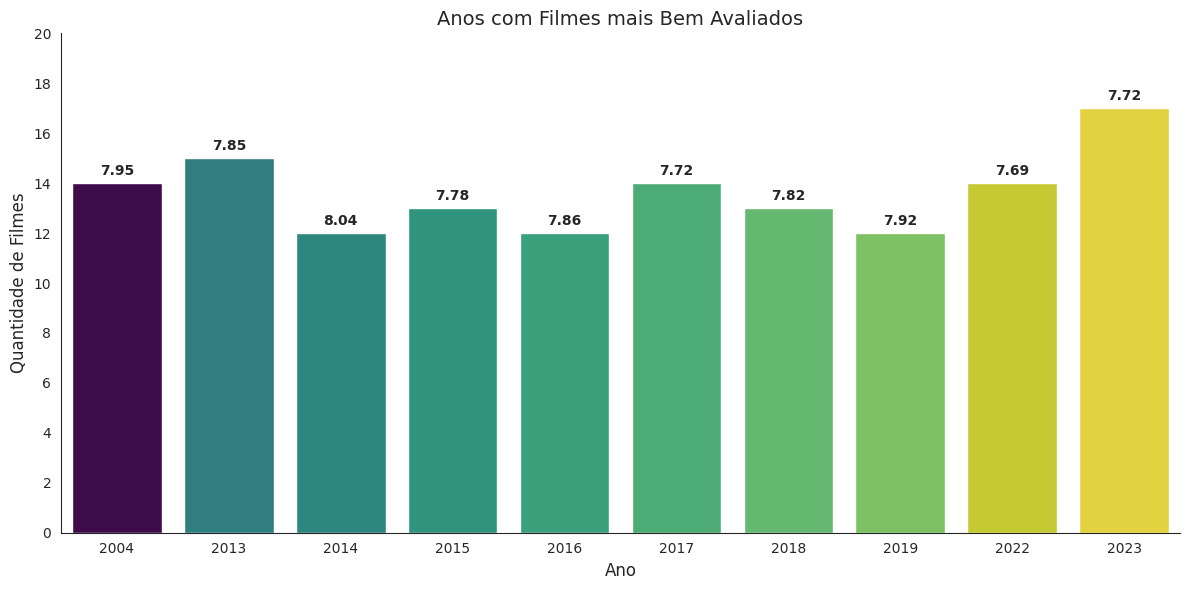

In [14]:
top_10_years_data = year_summary.head(10).reset_index()
top_10_years_data = top_10_years_data.sort_values(by='Year')
sns.set_style("white")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_years_data, x='Year', y='movie_count', palette='viridis', hue='Year', legend=False)

for i, p in enumerate(ax.patches):
    mean_score = top_10_years_data.iloc[i]['mean_imdb_score']
    ax.annotate(f'{mean_score:.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title('Anos com Filmes mais Bem Avaliados', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Filmes', fontsize=12)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.ylim(0, top_10_years_data['movie_count'].max() + 3)
sns.despine()

plt.tight_layout()
plt.show()

Com base no gráfico da Média de Notas IMDb por Ano, podemos observar que os anos com o maior número de filmes entre os 500 melhores mantêm uma alta média de pontuação no IMDb, geralmente variando entre 7.7 e 8.0. Isso sugere que a produção de um grande volume de filmes em um determinado ano não necessariamente dilui a qualidade média, com muitos anos demonstrando consistência na criação de filmes bem avaliados pela crítica e pelo público.

#Filmes com maior número de votos no IMDb

In [15]:
top_voted_movies = df_limpo.sort_values(by='IMDb_Votes', ascending=False)
display(top_voted_movies.head(10)[['Rank', 'Title', 'IMDb_Votes']])

,Rank,Title,IMDb_Votes
215,216,Inception,2666368
271,272,Fight Club,2444413
102,103,Forrest Gump,2362620
6,7,Pulp Fiction,2319136
265,266,Interstellar,2317550
332,333,The Matrix,2141445
0,1,The Godfather,2108796
32,33,The Lord of the Rings: The Fellowship of the Ring,2094033
27,28,The Lord of the Rings: The Return of the King,2064721
322,323,Se7en,1895482


Com base na análise dos filmes com maior número de votos no IMDb, observamos que o filme 'Inception' lidera com a maior quantidade de votos, seguido por 'Fight Club' e 'Forrest Gump'. É interessante notar a presença de filmes como 'Pulp Fiction' e 'O Poderoso Chefão' entre os mais votados, indicando a preferência do público por clássicos e filmes aclamados que perduram ao longo do tempo.

#Produtoras com mais filmes e suas notas médias no IMDb

In [16]:
produtora_imdb_scores = []
for index, row in df_limpo.iterrows():
    if pd.isna(row['Production']):
        continue
    produtoras = [p.strip() for p in row['Production'].split(',')]
    for produtora in produtoras:
        produtora_imdb_scores.append({'Production': produtora, 'IMDb_10_Score': row['IMDb_10']})

produtora_scores_df = pd.DataFrame(produtora_imdb_scores)
produtora_summary = produtora_scores_df.groupby('Production').agg(
    movie_count=('IMDb_10_Score', 'count'),
    mean_imdb_score=('IMDb_10_Score', 'mean')
).sort_values(by='movie_count', ascending=False)
produtora_summary.head(10).round(2)

,movie_count,mean_imdb_score
Production,,
Warner Bros. Pictures,24,8.14
Paramount Pictures,21,8.28
Sony Pictures Classics,19,7.97
United Artists,16,8.14
Universal Pictures,14,8.06
Miramax Films,13,8.22
20th Century Fox,12,8.16
MGM,9,7.89
Focus Features,9,7.93


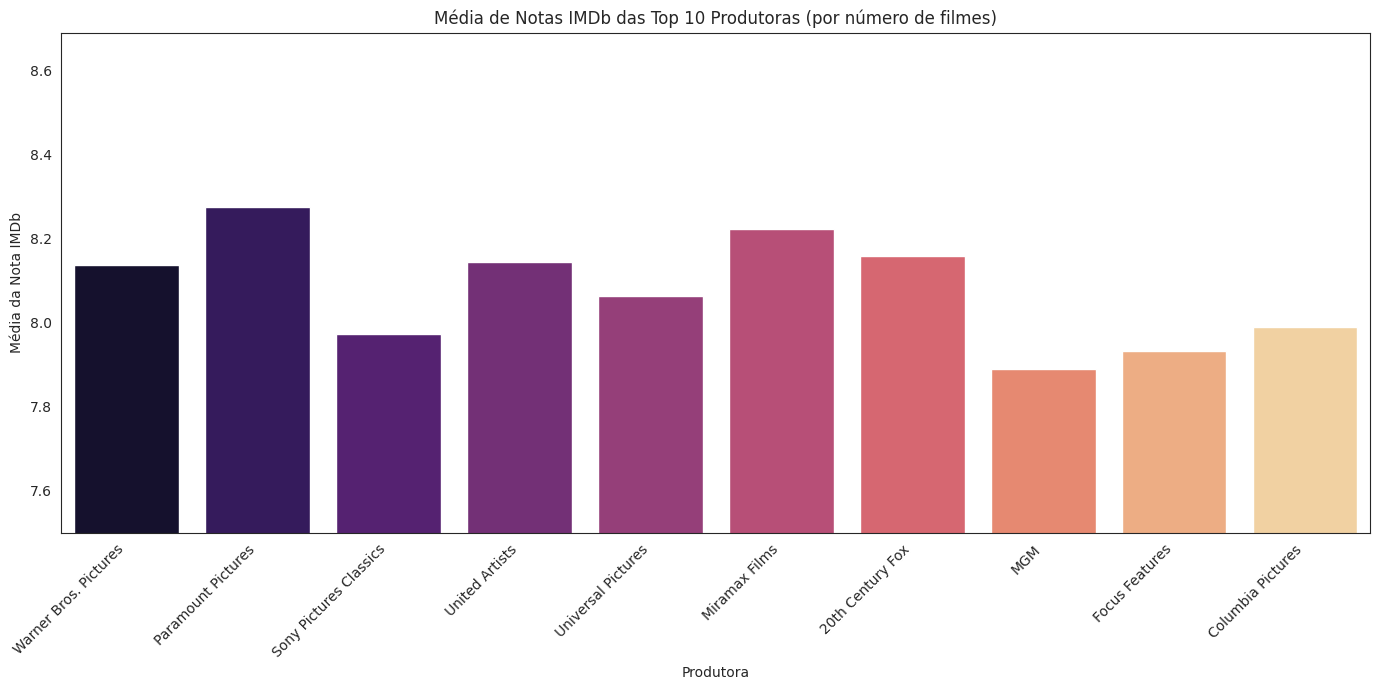

In [17]:
plt.figure(figsize=(14, 7))
sns.barplot(x=produtora_summary.head(10).index, y=produtora_summary.head(10)['mean_imdb_score'], palette='magma', hue=produtora_summary.head(10).index, legend=False)
plt.title('Média de Notas IMDb das Top 10 Produtoras (por número de filmes)')
plt.xlabel('Produtora')
plt.ylabel('Média da Nota IMDb')
plt.xticks(rotation=45, ha='right')
plt.ylim(bottom=7.5)
plt.tight_layout()
plt.show()

# Análise da Frequência de Atores com Produtoras

In [18]:
actor_director_combinations = []

for index, row in df_limpo.iterrows():
    if pd.isna(row['Director']) or pd.isna(row['Cast']):
        continue

    actors = [actor.strip() for actor in row['Cast'].split(',')]
    directors = [director.strip() for director in row['Director'].split(',')]
    for actor in actors:
        for director in directors:
            actor_director_combinations.append({'Actor': actor, 'Director': director})
actor_director_df = pd.DataFrame(actor_director_combinations)
actor_director_frequency = actor_director_df.groupby(['Actor', 'Director']).size().reset_index(name='Frequency')

top_actor_director_pairs = actor_director_frequency.sort_values(by='Frequency', ascending=False)
print(top_actor_director_pairs.head(10).to_string(index=False))

          Actor          Director  Frequency
 Robert De Niro   Martin Scorsese          6
      Joe Pesci   Martin Scorsese          4
    Ethan Hawke Richard Linklater          4
    Julie Delpy Richard Linklater          3
   Ian McKellen     Peter Jackson          3
  Harvey Keitel   Martin Scorsese          3
Viggo Mortensen     Peter Jackson          3
    Uma Thurman Quentin Tarantino          3
    Elijah Wood     Peter Jackson          3
     Sean Astin     Peter Jackson          3


/tmp/ipykernel_72764/768453397.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


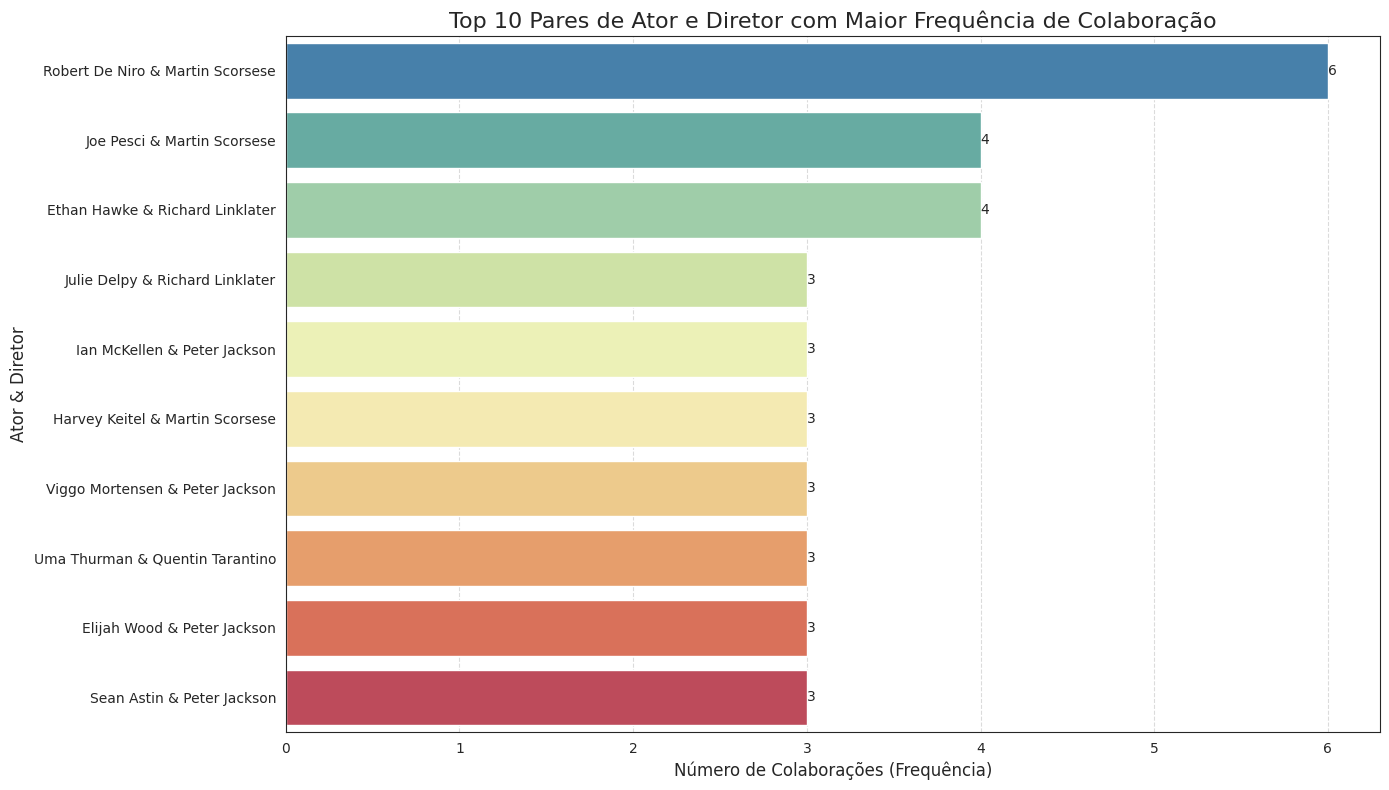

In [19]:
top_actor_director_pairs['Actor_Director'] = top_actor_director_pairs['Actor'] + ' & ' + top_actor_director_pairs['Director']

plt.figure(figsize=(14, 8))

sns.barplot(
    x='Frequency',
    y='Actor_Director',
    data=top_actor_director_pairs.head(10),
    palette='Spectral_r'
)

plt.title('Top 10 Pares de Ator e Diretor com Maior Frequência de Colaboração', fontsize=16)
plt.xlabel('Número de Colaborações (Frequência)', fontsize=12)
plt.ylabel('Ator & Diretor', fontsize=12)

for index, value in enumerate(top_actor_director_pairs['Frequency'].head(10)):
    plt.text(value, index, str(value), ha='left', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A análise da frequência de combinações entre atores e diretores revelou os pares que mais colaboram. Esta tabela mostra os 10 principais pares de atores e diretores que aparecem juntos no maior número de filmes dentro do nosso dataset. Isso pode indicar parcerias criativas duradouras ou a preferência de certos diretores por atores específicos, contribuindo para o estilo e sucesso dos filmes.

#Duplas Icônicas

In [20]:
actor_pairs_combinations = []

for index, row in df_limpo.iterrows():
    if pd.isna(row['Cast']):
        continue

    actors = [actor.strip() for actor in row['Cast'].split(',')]

    unique_actors = sorted(list(set(actors)))

    if len(unique_actors) >= 2:
        for pair in itertools.combinations(unique_actors, 2):
            actor_pairs_combinations.append({'Actor_1': pair[0], 'Actor_2': pair[1]})

actor_pairs_df = pd.DataFrame(actor_pairs_combinations)

actor_pairs_frequency = actor_pairs_df.groupby(['Actor_1', 'Actor_2']).size().reset_index(name='Frequency')

top_actor_pairs = actor_pairs_frequency.sort_values(by='Frequency', ascending=False)
print(top_actor_pairs.head(10).to_string(index=False))

      Actor_1         Actor_2  Frequency
    Joe Pesci  Robert De Niro          4
Harvey Keitel  Robert De Niro          3
   Sean Astin Viggo Mortensen          3
    Tim Allen       Tom Hanks          3
    Al Pacino  Robert De Niro          3
  Ethan Hawke     Julie Delpy          3
  Elijah Wood Viggo Mortensen          3
 Ian McKellen Viggo Mortensen          3
  Elijah Wood      Sean Astin          3
  Elijah Wood    Ian McKellen          3


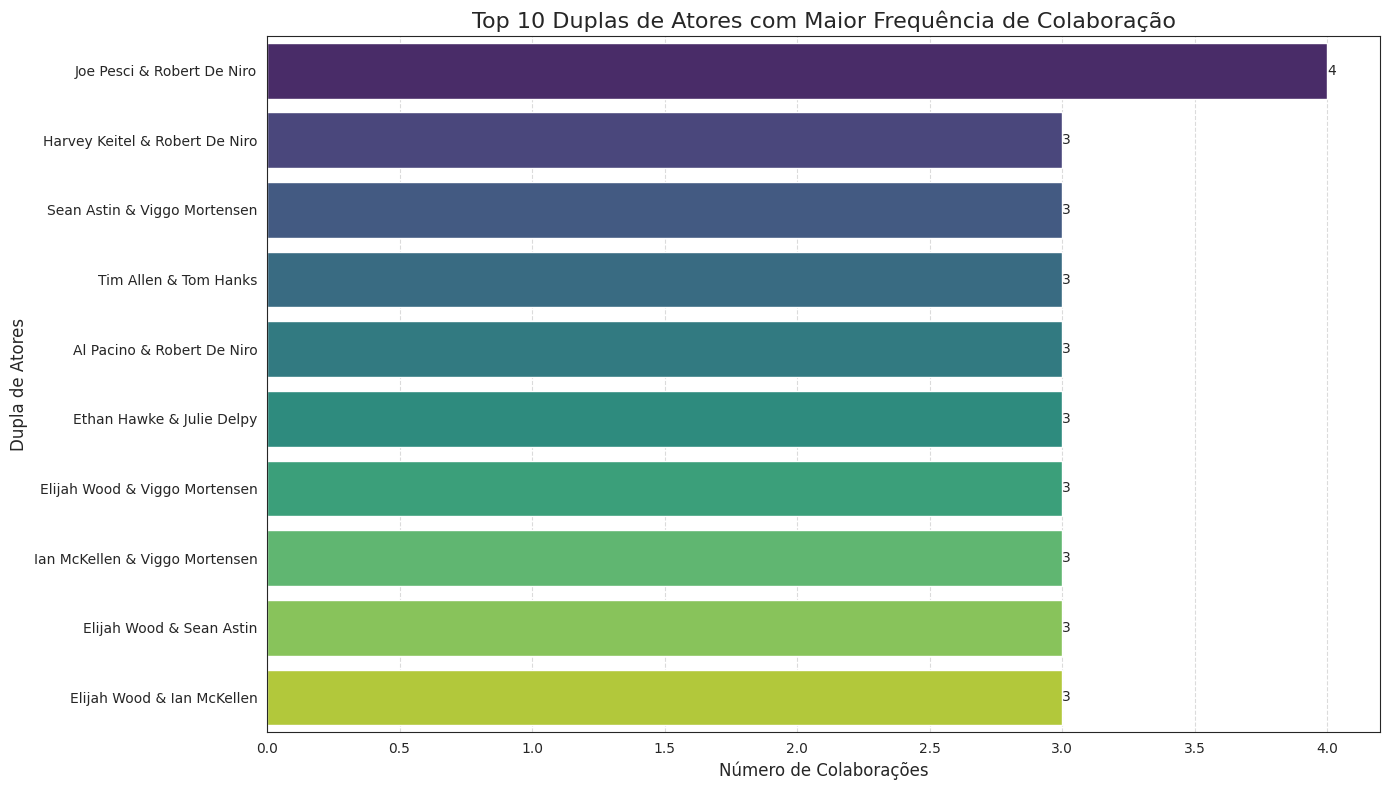

In [21]:
top_actor_pairs['Actor_Pair'] = top_actor_pairs['Actor_1'] + ' & ' + top_actor_pairs['Actor_2']

plt.figure(figsize=(14, 8))

sns.barplot(
    x='Frequency',
    y='Actor_Pair',
    data=top_actor_pairs.head(10),
    palette='viridis',
    hue='Actor_Pair',
    legend=False
)

plt.title('Top 10 Duplas de Atores com Maior Frequência de Colaboração', fontsize=16)
plt.xlabel('Número de Colaborações', fontsize=12)
plt.ylabel('Dupla de Atores', fontsize=12)

for index, value in enumerate(top_actor_pairs['Frequency'].head(10)):
    plt.text(value, index, str(value), ha='left', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Esta análise revela os pares de atores que mais colaboram em filmes dentro do nosso dataset. A tabela acima mostra os 10 pares de atores que apareceram juntos no maior número de filmes. Essas parcerias frequentes podem indicar uma forte química em tela, preferências de diretores ou produtoras, ou até mesmo um atrativo comercial comprovado para o público.

# Conclusão

---


Esta análise exploratória revelou que o sucesso
crítico e popular no cinema é sustentado por uma combinação de fatores consistentes. Observamos que o gênero Drama é o pilar fundamental das obras mais bem avaliadas, sugerindo uma preferência por narrativas com maior profundidade emocional. Além disso, a presença recorrente de diretores como Steven Spielberg e Martin Scorsese, e de atores como Robert De Niro, demonstra que a experiência e o talento consolidado mantêm um padrão de excelência ao longo de décadas. Por fim, identificamos que parcerias criativas icônicas e um alto volume de votos em clássicos modernos reforçam que a qualidade técnica, quando aliada a uma boa química entre elenco e direção, resulta em obras que permanecem relevantes e aclamadas pelo público e pela crítica ao longo do tempo.


Dataset utilizado: https://www.kaggle.com/datasets/prashant0kumar7/top-500-movies-ranked-by-combined-critics/data
